In [2]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Cargar modelo y datos
gb        = joblib.load('../data/modelo_gb_dulce_agrio.pkl')
scaler_gb = joblib.load('../data/scaler_dulce_agrio.pkl')

df = pd.read_csv('../data/crude_oil_clean.csv')
df['DULCE_AGRIO'] = (df['SRC'] >= 0.5).astype(int)

FEATURES = [
    'API_CRUDE', 'CRN', 'SU100', 'POUR_POINT',
    'CAR_CR_WT', 'LT_GAS_VOL', 'GAS_NP_VOL', 'RESDUM_VOL'
]

NOMBRES = {
    'API_CRUDE':   'Gravedad API',
    'CRN':         'Nitrógeno (%)',
    'SU100':       'Viscosidad 100°F',
    'POUR_POINT':  'Punto de fluidez',
    'CAR_CR_WT':   'Residuo carbono (%)',
    'LT_GAS_VOL':  'Vol. gasolina ligera',
    'GAS_NP_VOL':  'Vol. gasolina/nafta',
    'RESDUM_VOL':  'Vol. residuo'
}

X = df[FEATURES].copy()
y = df['DULCE_AGRIO'].copy()

X_scaled = scaler_gb.transform(X)
_, X_test, _, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Crear DataFrame con nombres legibles para SHAP
X_test_df = pd.DataFrame(X_test, columns=[NOMBRES[f] for f in FEATURES])

print(f'Muestras de test: {len(X_test_df):,}')
print('Calculando valores SHAP...')

# Calcular SHAP
explainer   = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

print('Listo.')

Muestras de test: 1,769
Calculando valores SHAP...
Listo.


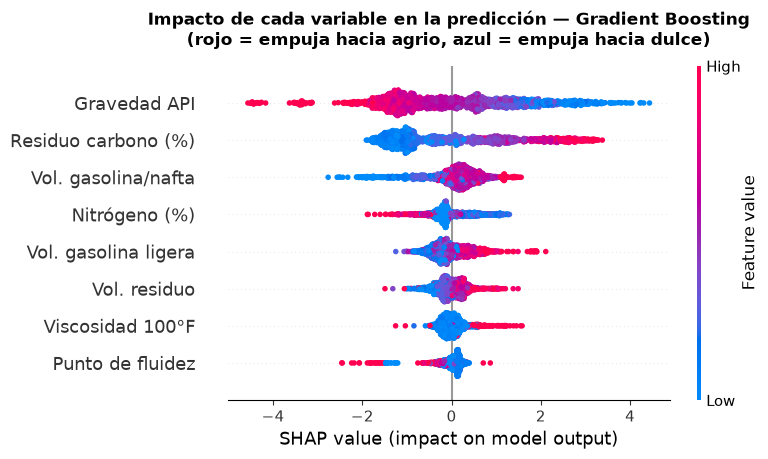

Gráfico 1 guardado.


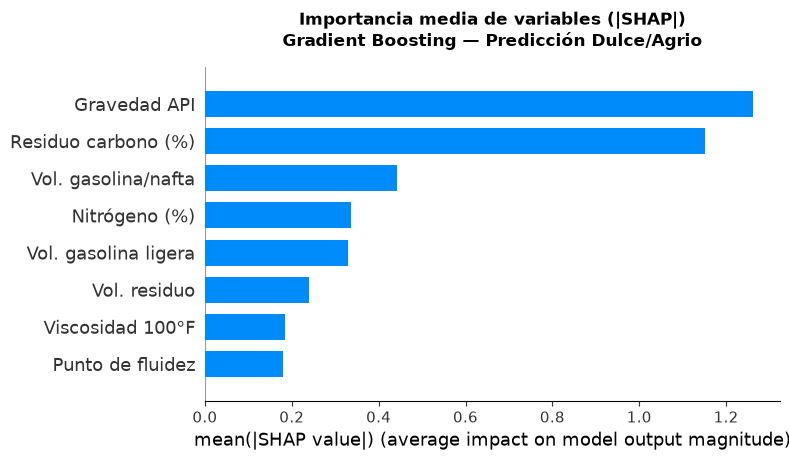

Gráfico 2 guardado.


In [3]:
# ── GRÁFICO 1: Importancia global (beeswarm) ─────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_df,
    plot_type='dot',
    show=False
)
plt.title('Impacto de cada variable en la predicción — Gradient Boosting\n'
          '(rojo = empuja hacia agrio, azul = empuja hacia dulce)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 1 guardado.')

# ── GRÁFICO 2: Importancia global (barras) ───────────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_test_df,
    plot_type='bar',
    show=False
)
plt.title('Importancia media de variables (|SHAP|)\n'
          'Gradient Boosting — Predicción Dulce/Agrio',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/shap_importancia_barras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 2 guardado.')

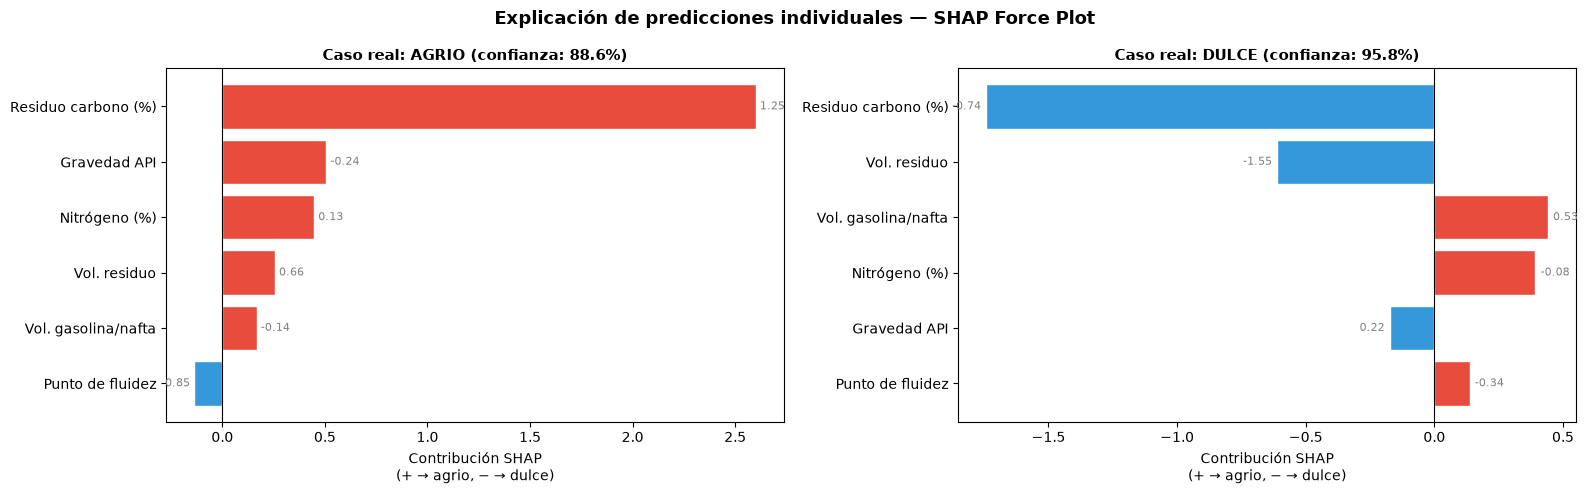

Gráfico 3 guardado.


In [4]:
# ── GRÁFICO 3: Explicación de una muestra individual ─────────
# Tomamos un crudo agrio real del test set para explicar la predicción

# Buscar un caso agrio con alta confianza
probas    = gb.predict_proba(X_test)[:, 1]
idx_agrio = np.where((y_test.values == 1) & (probas > 0.85))[0][0]
idx_dulce = np.where((y_test.values == 0) & (probas < 0.15))[0][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Explicación de predicciones individuales — SHAP Force Plot',
             fontsize=13, fontweight='bold')

for ax, idx, titulo in [
    (axes[0], idx_agrio, f'Caso real: AGRIO (confianza: {probas[idx_agrio]*100:.1f}%)'),
    (axes[1], idx_dulce, f'Caso real: DULCE (confianza: {(1-probas[idx_dulce])*100:.1f}%)')
]:
    valores_shap   = shap_values[idx]
    valores_feat   = X_test_df.iloc[idx]
    nombres_feat   = X_test_df.columns.tolist()

    # Ordenar por valor absoluto
    orden = np.argsort(np.abs(valores_shap))[::-1][:6]

    colores = ['#e74c3c' if v > 0 else '#3498db' for v in valores_shap[orden]]
    bars = ax.barh(
        [nombres_feat[i] for i in orden][::-1],
        valores_shap[orden][::-1],
        color=colores[::-1], edgecolor='white'
    )
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Contribución SHAP\n(+ → agrio, − → dulce)')

    # Anotar valores reales de las features
    for bar, i in zip(bars, orden[::-1]):
        val_real = valores_feat[nombres_feat[i]]
        ax.text(
            bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val_real:.2f}',
            va='center',
            ha='left' if bar.get_width() >= 0 else 'right',
            fontsize=8, color='gray'
        )

plt.tight_layout()
plt.savefig('../data/shap_casos_individuales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 3 guardado.')